In [5]:
import subprocess
import pandas as pd 
import numpy as np 



In [80]:
path = "/Users/mariekevandeven/stage_fragmentomics/data/EE85723.hg38.frag.tsv.bgz"

max_len = 300

def process_sample(path, MPQ_cutoff = 55):
    counts = np.zeros(max_len + 1, dtype = int)

    proc = subprocess.Popen(
        ['bgzip', '-cd', path],
        stdout = subprocess.PIPE,
        text = True
)

    for line in proc.stdout:
        chr_name, start, end, mapQ, strand = line.rstrip().split('\t')

        if int(mapQ) < MPQ_cutoff:
            continue

        length = int(end) - int(start)

        if length <= max_len:
            counts[length] += 1
        else:
            counts[max_len] += 1

    return pd.Series(
    counts,
    index = list(range(max_len)) + ['300+']
)


In [81]:
series = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85723.hg38.frag.tsv.bgz")
print(series)

0       0
1       0
2       3
3       4
4       5
       ..
296     0
297     0
298     0
299     0
300+    0
Length: 301, dtype: int64


<Axes: >

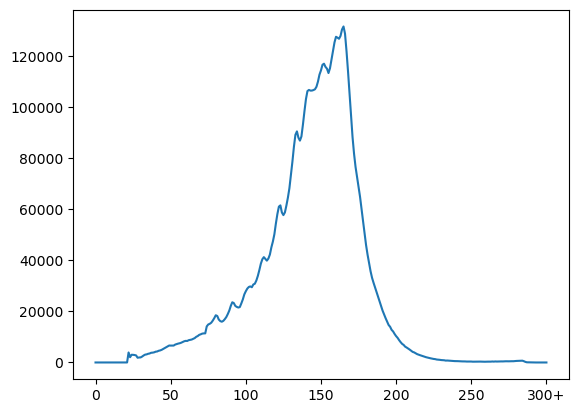

In [82]:
series.plot()

In [1]:
s1 = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85723.hg38.frag.tsv.bgz")
s2 = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85724.hg38.frag.tsv.bgz")
s3 = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85725.hg38.frag.tsv.bgz")
s4 = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85726.hg38.frag.tsv.bgz") 
s5 = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85727.hg38.frag.tsv.bgz")
s6 = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85728.hg38.frag.tsv.bgz")
s7 = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85729.hg38.frag.tsv.bgz")
s8 = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85730.hg38.frag.tsv.bgz")
s9 = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85734.hg38.frag.tsv.bgz")
s10 = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85735.hg38.frag.tsv.bgz")

NameError: name 'process_sample' is not defined

In [84]:
df = pd.DataFrame([s1, s2, s3, s4, s5, s6, s7, s8, s9, s10])

In [85]:
df.index = ['EE85723', 'EE85725', 'EE85727', 'EE85728', 'EE85726', 'EE85724', 'EE85730', 'EE85729', 'EE85734', 'EE85735']

<Axes: >

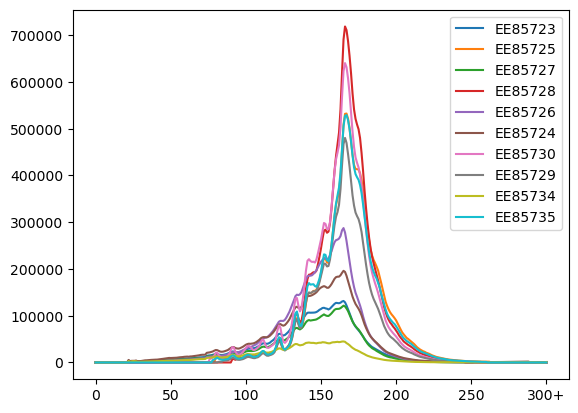

In [86]:
df.T.plot()

In [87]:
df.iloc[:, 150:171]

,150,151,152,153,154,155,156,157,158,159,...,161,162,163,164,165,166,167,168,169,170
EE85723,114356,116533,116981,115730,115013,113313,115202,118525,121788,125318,...,127157,126728,127842,130367,131545,128710,121856,113938,105394,96711
EE85725,189929,208073,223846,222512,214036,213183,226334,251122,281230,312666,...,350912,365866,399312,454299,508085,531834,532457,521644,501473,472565
EE85727,98604,100629,102858,100874,99691,99463,101954,105035,108894,112601,...,114479,114794,116237,118965,121430,119961,115415,110035,102160,94788
EE85728,243790,264145,281865,284087,277457,279933,298150,328267,369139,408931,...,465517,491553,541240,618960,690668,718692,710899,687733,656241,618683
EE85726,215379,219475,222757,221721,221291,222604,230073,237691,248193,257051,...,262754,265012,270402,282531,287488,278098,259973,238632,216425,195369
EE85724,160259,162026,163281,162044,159766,159864,163036,167516,173451,178891,...,183504,183593,186530,191625,196034,193726,185377,174314,164033,151380
EE85730,262785,280796,298283,296371,286014,284958,300430,331868,369416,408104,...,448704,464751,503270,567710,623250,640377,631572,608091,575863,535454
EE85729,185085,199253,211585,211039,205416,206430,220098,243622,269310,293433,...,321562,337230,371039,421727,467050,480331,469584,446346,419454,387824
EE85734,42237,43334,43116,42643,41623,41034,41040,42462,43212,43324,...,44185,43500,43945,44798,44937,44229,41458,39471,36975,33882
EE85735,194491,213549,231283,230175,218980,216694,227723,251686,280906,314482,...,357692,374311,406534,456233,505581,527540,529271,518518,499618,473485
